In [1]:
from option_chain_downloader import OptionChainDownloader
from option_finder import *
from option_data_plotter import *
import matplotlib.pyplot as plt

In [2]:
try:
    logger
except NameError:
    logger = get_rotating_logger("jupyter", f'logs/options_non_leaps.log')

In [3]:
chain_dir = 'chain'
quotes_dir = 'quotes'
leaps_dir = 'leaps'
data_dir = 'data'
cookie_file = 'cookie.txt'
ocd = OptionChainDownloader(chain_dir, quotes_dir, leaps_dir, cookie_file, logger, strikes='ALL')
self = OptionFinder(logger, chain_dir=chain_dir, report_dir=data_dir)
print('OptionFinder chain_dir:', self.chain_dir)

OptionFinder chain_dir: chain


In [4]:
#symlist = ['GLD', 'QQQ'] # TLT GLD IBIT'.split(' ')
symlist = 'QQQ SPY TLT DIA IBIT ETHA GLD SLV CRCL'.split(' ')
#symlist = 'CRCL META AMD AMZN CRWV UNH OKLO TSLA'.split(' ')
#symlist = 'QQQ SPY TLT DIA IBIT GLD'.split(' ')

## Refresh data here

In [5]:
_t0 = time.time()
_n = ocd.download_option_chain(symlist, batch_size=5, rps=5)
print(_n, 'files downloaded', int(time.time() - _t0), 'seconds')

27 files downloaded 5 seconds


In [7]:
self.get_quote_df(symlist)
_df = self.build_option_df(symlist)
df_cp = self.concat_put_call_options(_df)
check_data_age(_df)

,quote_age,load_age,quote_dt,load_dt
symbol,,,,
CRCL,10,8,0,0
DIA,10,7,0,0
ETHA,10,9,0,0
GLD,7,3,0,0
IBIT,9,7,0,0
QQQ,6,2,0,0
SLV,8,6,0,0
SPY,6,1,0,0
TLT,12,10,0,0


### Puts/calls ratios for all strikes

,Volume_all,OpenInterest_all,Volume,OpenInterest
symbol,,,,
CRCL,0.822911,0.734285,1.291018,0.999429
DIA,1.314089,1.423122,1.629540,0.846886
ETHA,0.416353,0.613526,0.986345,0.803274
GLD,0.177507,0.716224,0.311125,0.376630
IBIT,0.375579,0.431936,0.509941,0.539768
QQQ,0.767054,1.638301,0.738046,1.790211
SLV,0.374589,0.746839,0.463774,0.836879
SPY,0.924106,3.022775,0.863647,1.845744
TLT,0.643253,0.666146,0.620817,0.929140


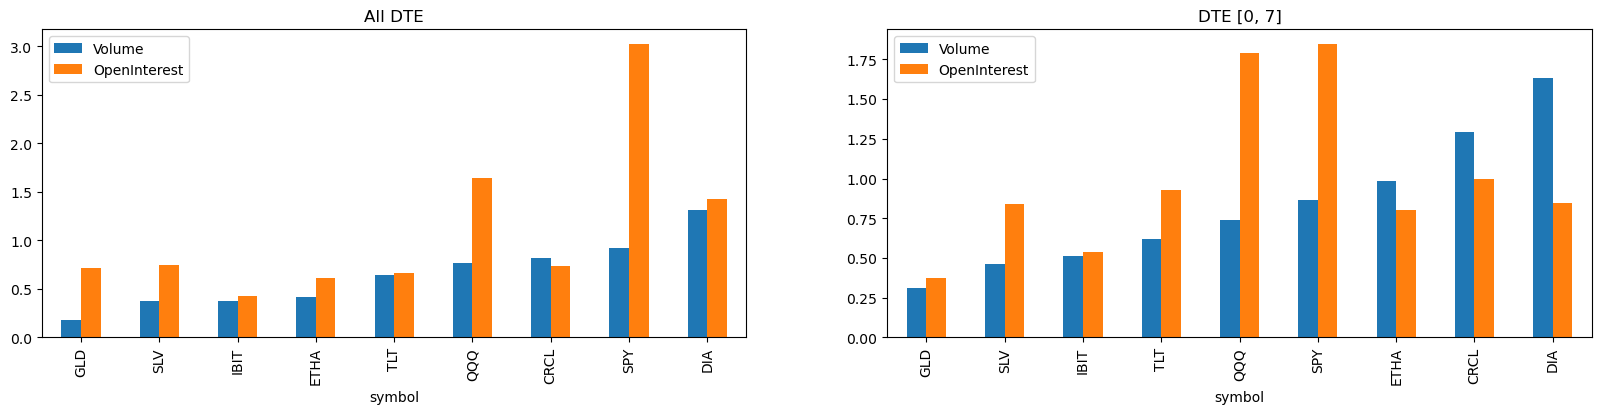

In [15]:
plt.rcParams['figure.figsize'] = (20, 4)
fig, ax = plt.subplots(1, 2)
df_all = self.overall_put_call_ratios(df_cp)
dte_range = [0, 7]
df1 = self.overall_put_call_ratios(df_cp, dte_range)
df_all.sort_values(by='Volume').plot(kind='bar', ax=ax[0], title='All DTE')
df1.sort_values(by='Volume').plot(kind='bar', ax=ax[1], title=f'DTE {dte_range}')
df_all.join(df1, lsuffix='_all')

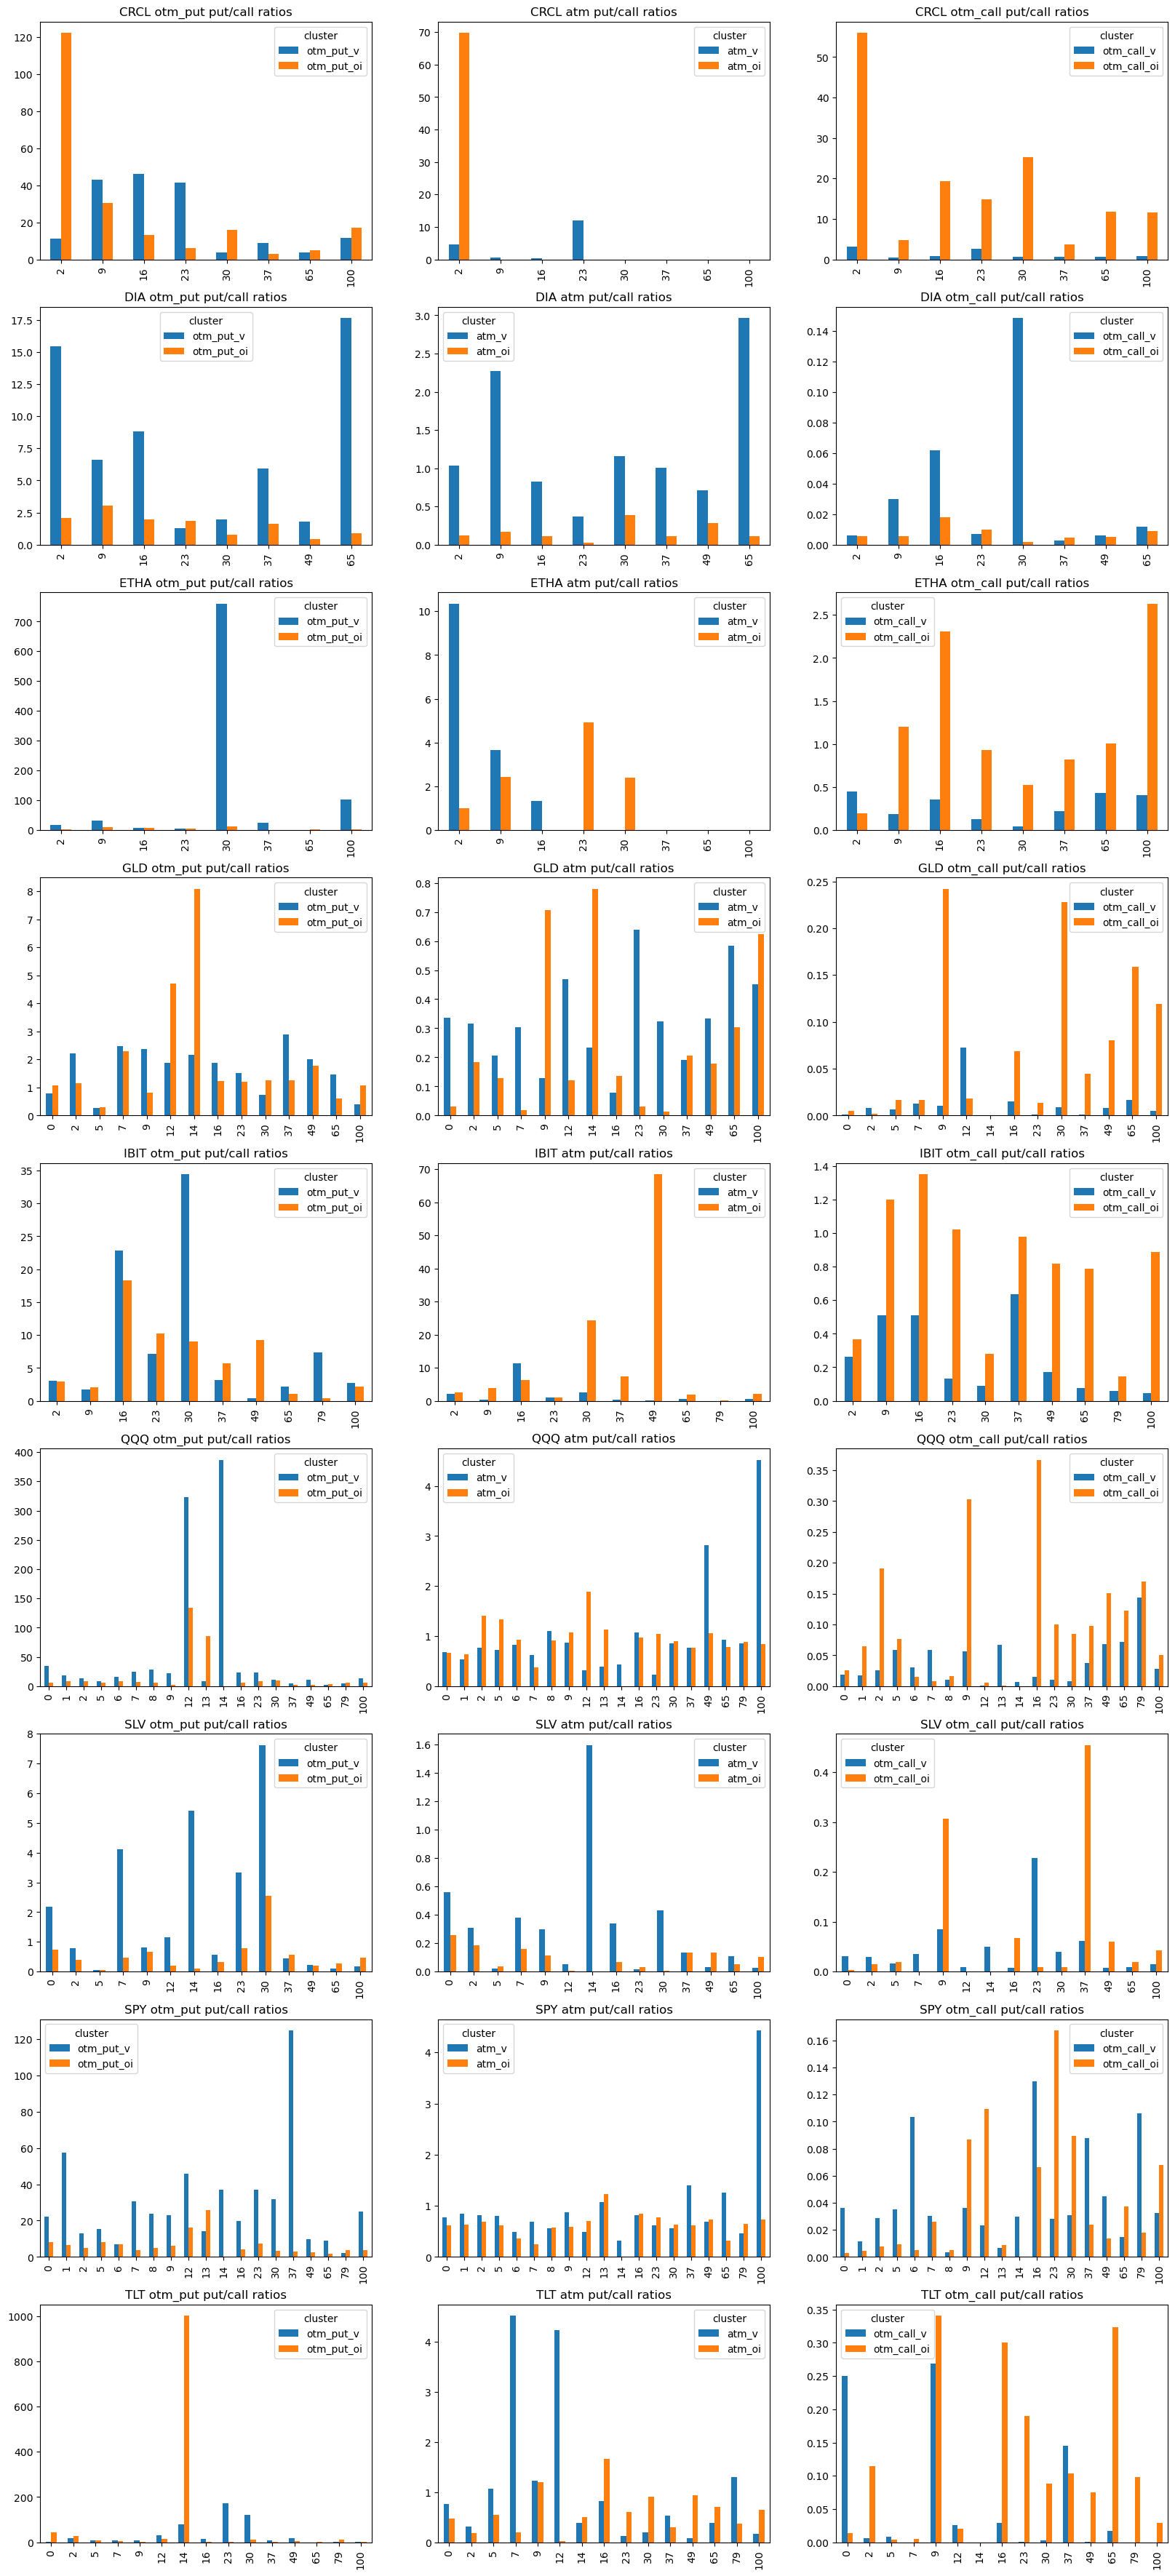

In [17]:
df_moneyness  = add_moneyness_columns(df_cp, atm_offset=0.01, otm_offset=0.1)
_df = plot_put_call_ratios_by_moneyness(df_moneyness)

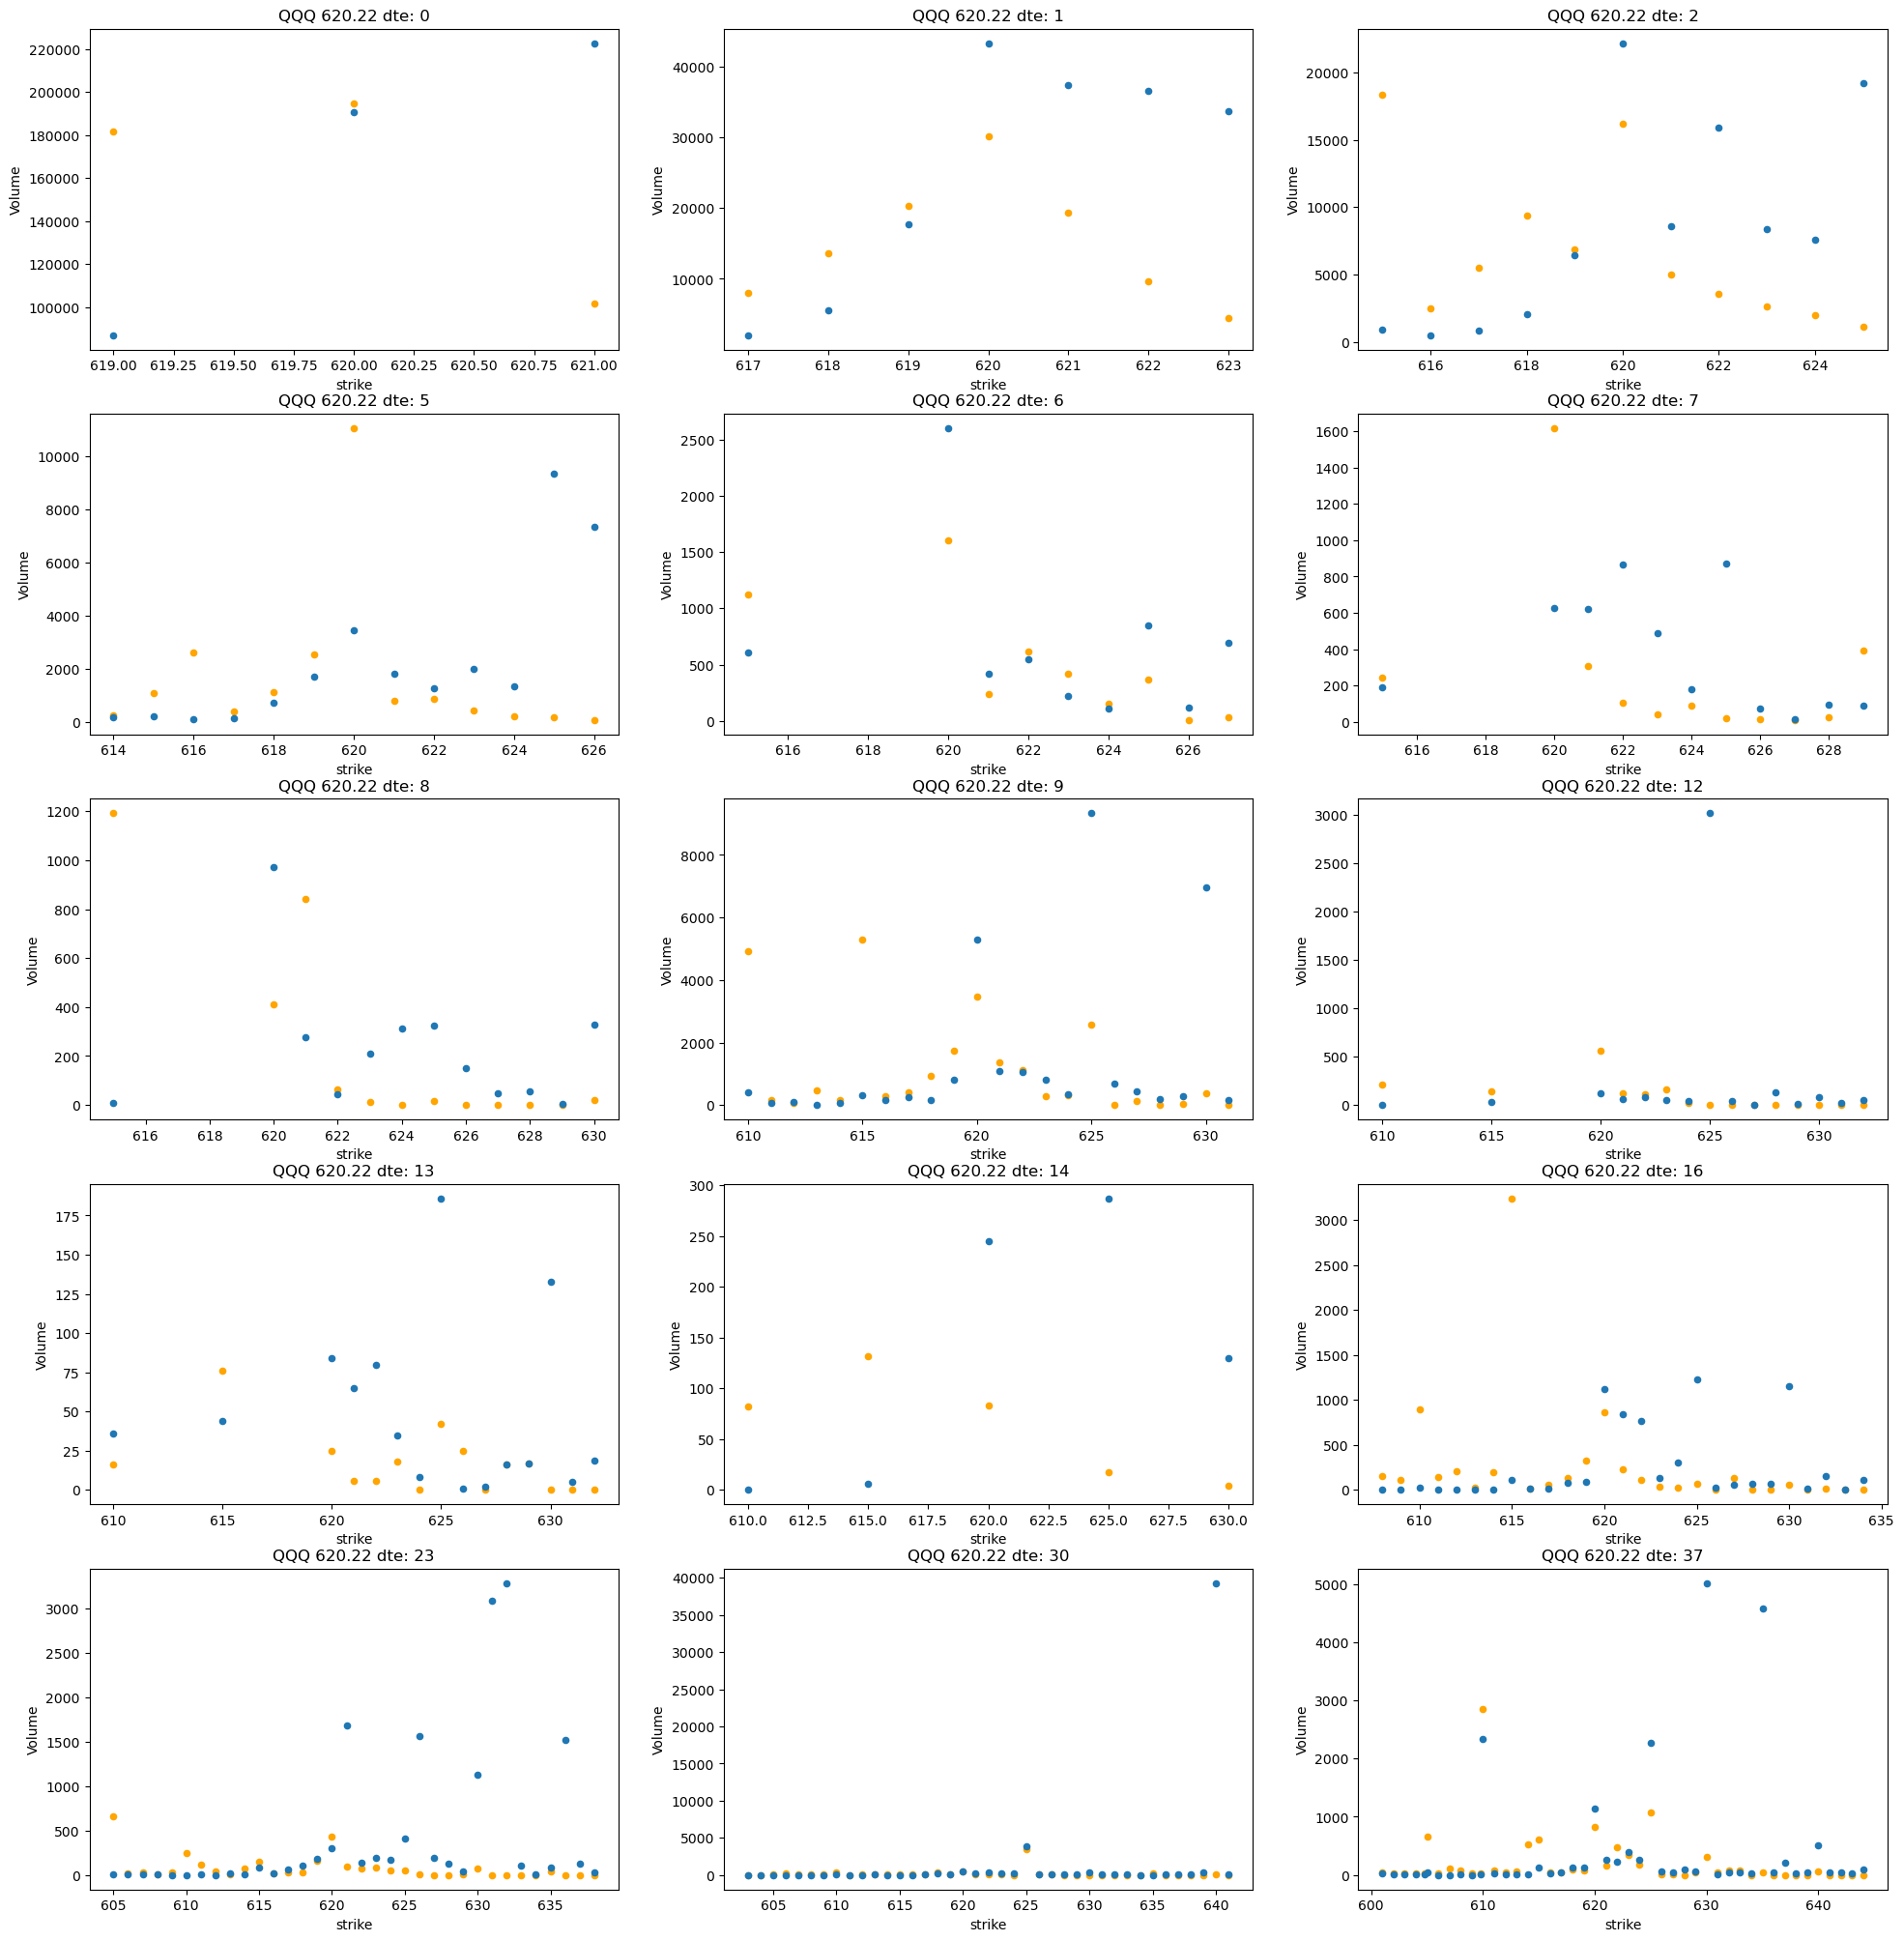

In [22]:
plot_option_details_by_dte(df_cp, 'QQQ', 'Volume', delta_lb=0.3, delta_ub=0.7, nr=5, nc=3)

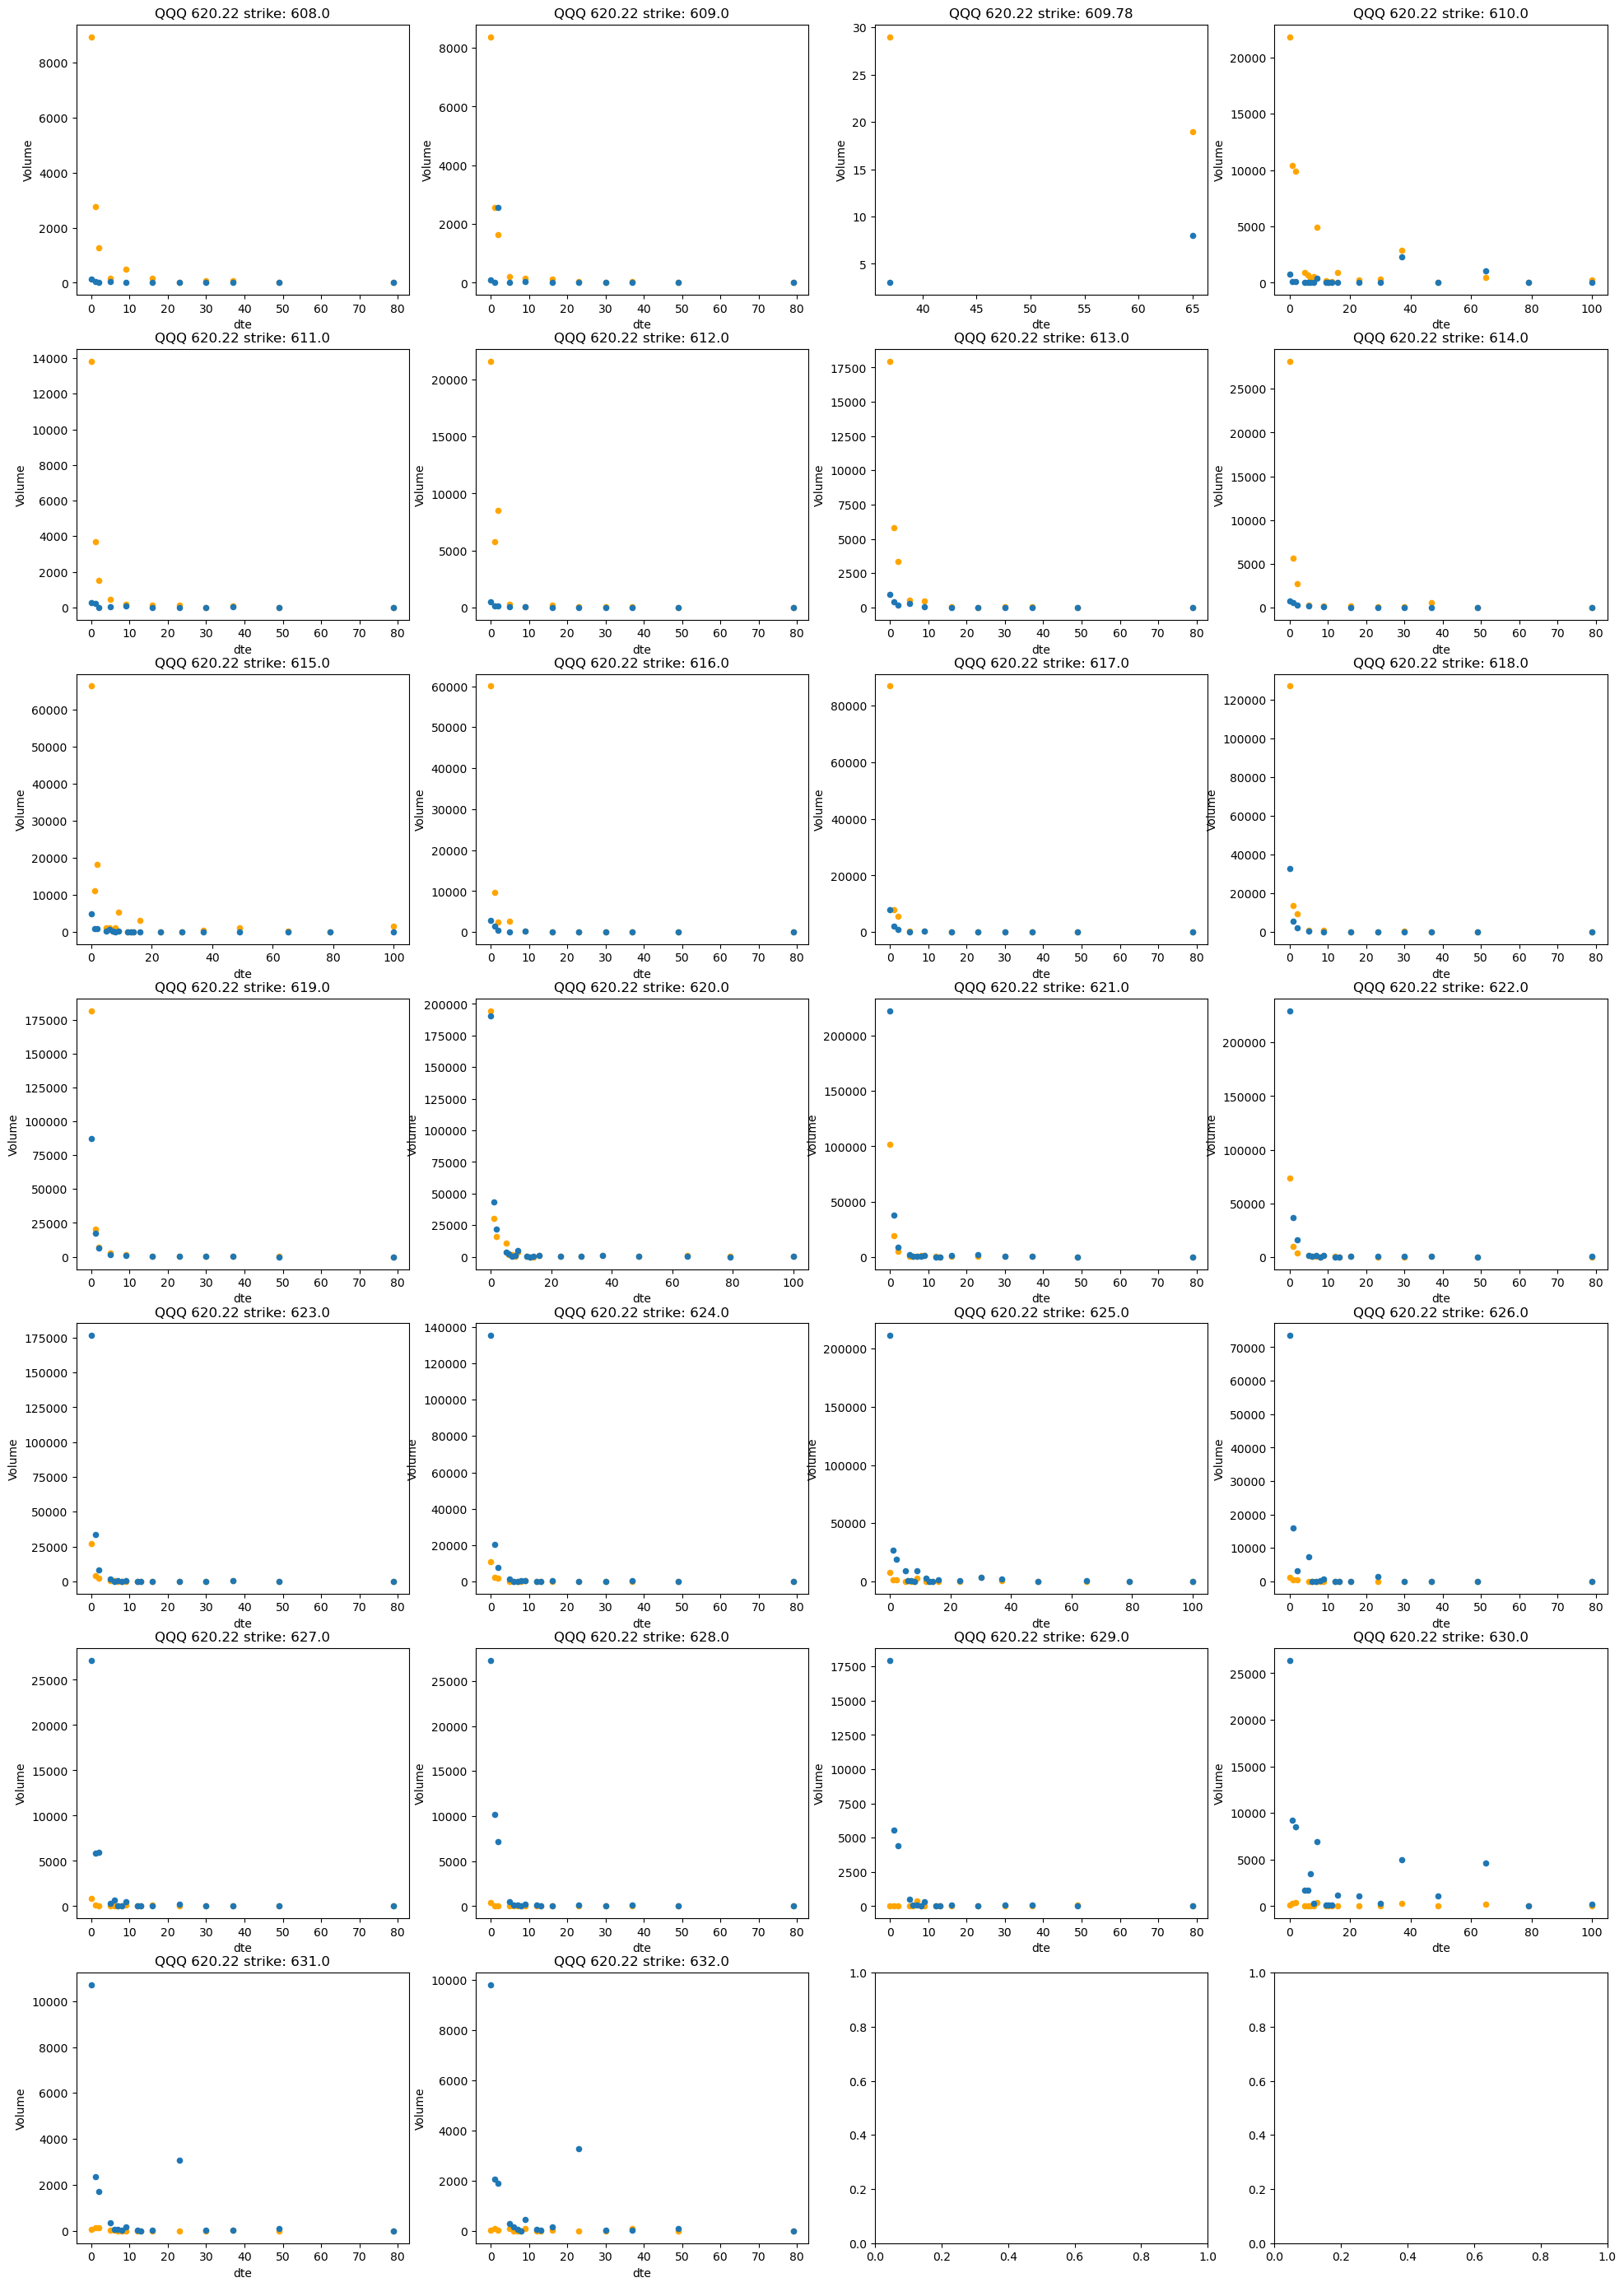

In [23]:
plot_option_details_by_strike(df_cp, 'QQQ', 'Volume', [0.98, 1.02])

### The End